# Модель SIR (эпидемиологическая модель)

Стандартная compartmental-модель распространения инфекционного заболевания
в однородной закрытой популяции без демографических процессов.

## Теоретические основы

Население делится на три эпидемиологических компартмента:
- **S** (*Susceptible*) — восприимчивые к заражению;
- **I** (*Infectious*) — инфицированные и заразные;
- **R** (*Recovered*) — выздоровевшие и иммунные.

Система ОДУ:

$$\frac{dS}{dt} = -\frac{\beta c I}{N} S$$
$$\frac{dI}{dt} = \frac{\beta c I}{N} S - \gamma I$$
$$\frac{dR}{dt} = \gamma I$$

где $N = S + I + R = \text{const}$ — общая численность популяции.

| Параметр | Значение | Смысл                                       |
|----------|----------|---------------------------------------------|
| $\beta$  | 0.05     | вероятность заражения при одном контакте    |
| $c$      | 10       | среднее число контактов в сутки             |
| $\gamma$ | 0.25     | скорость выздоровления (1/γ — длит. болезни)|

## Базовое репродуктивное число $R_0$

$$R_0 = \frac{\beta \cdot c}{\gamma}$$

- $R_0 > 1$ — эпидемия развивается;
- $R_0 < 1$ — вспышка затухает.

**Порог коллективного иммунитета**: $1 - 1/R_0$ доля популяции.

## Подключение пакетов

In [1]:
using DrWatson
@quickactivate "lab_02_models"
using DifferentialEquations
using SimpleDiffEq
using Tables
using DataFrames
using StatsPlots
using LaTeXStrings
using Plots
using BenchmarkTools

## Настройка рабочих директорий

In [2]:
script_name = "sir_ode"

"sir_ode"

## Определение правой части системы ОДУ

Функция `sir_ode!` вычисляет скорости изменения трёх компартментов.
Сила инфекции: $\lambda = \beta c I / N$.

In [3]:
function sir_ode!(du, u, p, t)
    (S, I, R) = u
    (β, c, γ) = p
    N = S + I + R
    @inbounds begin
        du[1] = -β * c * I / N * S          # dS/dt
        du[2] =  β * c * I / N * S - γ * I  # dI/dt
        du[3] =  γ * I                       # dR/dt
    end
    nothing
end

sir_ode! (generic function with 1 method)

## Параметры модели и начальные условия

In [4]:
δt    = 0.1
tmax  = 40.0
tspan = (0.0, tmax)
u0    = [990.0, 10.0, 0.0]   # [S₀, I₀, R₀]
p     = [0.05, 10.0, 0.25]   # [β, c, γ]

R0 = (p[2] * p[1]) / p[3]   # R₀ = (c·β) / γ

println("="^60)
println("Параметры модели SIR")
println("="^60)
println("β = $(p[1]),  c = $(p[2]),  γ = $(p[3])")
println("R₀ = c·β/γ = $(round(R0, digits=3))")
println("Средняя продолжительность болезни = $(round(1/p[3], digits=2)) дней")
println("Начальные условия: S₀=$(u0[1]), I₀=$(u0[2]), R₀=$(u0[3])")

Параметры модели SIR
β = 0.05,  c = 10.0,  γ = 0.25
R₀ = c·β/γ = 2.0
Средняя продолжительность болезни = 4.0 дней
Начальные условия: S₀=990.0, I₀=10.0, R₀=0.0


## Численное решение задачи

По умолчанию `solve` выбирает метод автоматически.
Для SIR подходит любой явный метод Рунге–Кутты (задача нежёсткая).

In [5]:
prob_ode = ODEProblem(sir_ode!, u0, tspan, p)
sol_ode  = solve(prob_ode, dt = δt)

retcode: Success
Interpolation: 3rd order Hermite
t: 15-element Vector{Float64}:
  0.0
  0.1
  0.5331242537191838
  1.3919008491040001
  2.6102120755226386
  4.1811820758323055
  6.180123810566044
  8.664951930903612
 11.691425331813486
 15.279370667110317
 19.082963490744028
 23.423425193442526
 28.42949373098617
 33.298779173639595
 40.0
u: 15-element Vector{Vector{Float64}}:
 [990.0, 10.0, 0.0]
 [989.4990153200853, 10.247898072276143, 0.25308660763853125]
 [987.1852964117763, 11.391111426852984, 1.4235921613706284]
 [981.8312125227972, 14.026022042698546, 4.14276543450428]
 [972.1392310589528, 18.757815561654187, 9.102953379393007]
 [954.9905500491583, 27.007702518267607, 18.00174743257403]
 [923.0706717929863, 41.92976779832721, 34.999560408686385]
 [862.6705810342164, 68.49345419063417, 68.83596477514932]
 [754.3022993851442, 109.74186185409279, 135.9558387607629]
 [595.1014268847736, 150.41363264480682, 254.48494047041947]
 [442.0141179101299, 154.80694988491865, 403.178932204951

## Подготовка данных

In [6]:
df_ode = DataFrame(Tables.table(sol_ode'))
rename!(df_ode, ["S", "I", "R"])
df_ode[!, :t] = sol_ode.t
df_ode[!, :N] = df_ode.S + df_ode.I + df_ode.R   # контроль сохранения N

15-element Vector{Float64}:
 1000.0
 1000.0
  999.9999999999999
 1000.0
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
  999.9999999999998
 1000.0
 1000.0
 1000.0
 1000.0

## Визуализация результатов

### График 1: Общая динамика эпидемии

Три кривые показывают «перетекание» популяции из $S$ через $I$ в $R$.

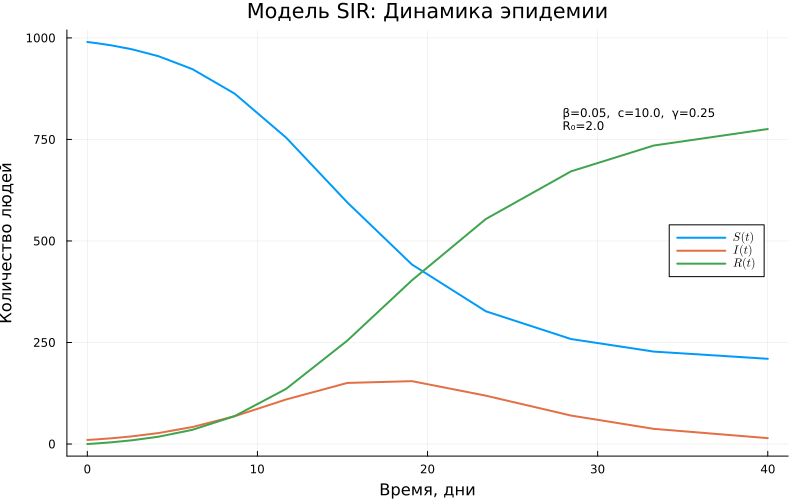

In [7]:
plt1 = @df df_ode plot(:t, [:S :I :R],
    label     = [L"S(t)" L"I(t)" L"R(t)"],
    xlabel    = "Время, дни",
    ylabel    = "Количество людей",
    title     = "Модель SIR: Динамика эпидемии",
    linewidth = 2,
    legend    = :right,
    grid      = true,
    size      = (800, 500))
annotate!(plt1, maximum(df_ode.t) * 0.7, maximum(df_ode.N) * 0.8,
    text("β=$(p[1]),  c=$(p[2]),  γ=$(p[3])\nR₀=$(round(R0, digits=2))", 8, :left))

### График 2: Динамика числа заражённых

Вертикальная линия обозначает момент пика эпидемии —
когда число новых заражений равно числу выздоровлений.

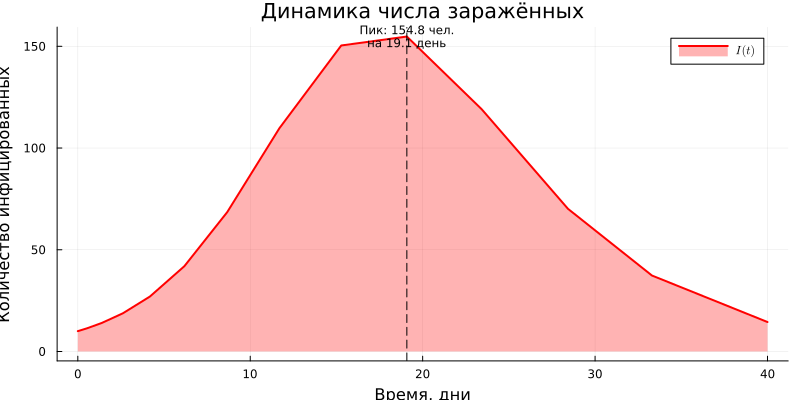

In [8]:
peak_idx   = argmax(df_ode.I)
peak_time  = df_ode.t[peak_idx]
peak_value = df_ode.I[peak_idx]

plt2 = @df df_ode plot(:t, :I,
    label     = L"I(t)",
    xlabel    = "Время, дни",
    ylabel    = "Количество инфицированных",
    title     = "Динамика числа заражённых",
    color     = :red,
    linewidth = 2,
    fill      = (0, 0.3, :red),
    grid      = true,
    size      = (800, 400))
vline!(plt2, [peak_time], color=:black, linestyle=:dash, label=false, linewidth=1)
annotate!(plt2, peak_time, peak_value * 1.05,
    text("Пик: $(round(peak_value, digits=1)) чел.\nна $(round(peak_time, digits=1)) день",
    8, :top))

### График 3: Логарифмический масштаб

В начале эпидемии рост $I(t)$ приближённо экспоненциален с показателем
$r = \gamma (R_0 - 1)$, что хорошо видно на логарифмической шкале.

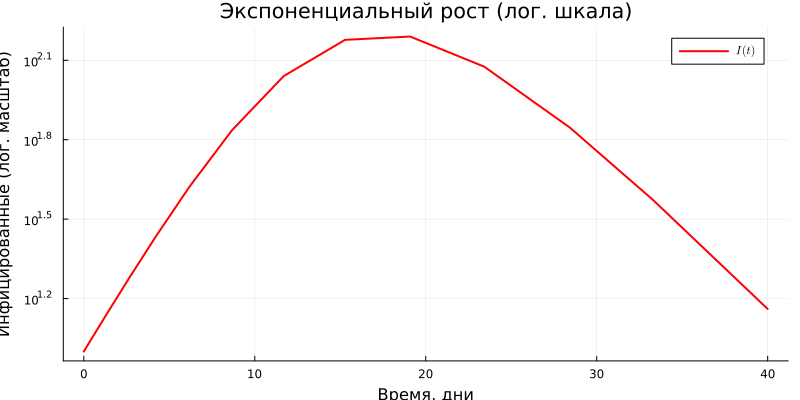

In [9]:
plt3 = @df df_ode plot(:t, :I,
    label     = L"I(t)",
    xlabel    = "Время, дни",
    ylabel    = "Инфицированные (лог. масштаб)",
    title     = "Экспоненциальный рост (лог. шкала)",
    yscale    = :log10,
    color     = :red,
    linewidth = 2,
    grid      = true,
    size      = (800, 400))

### График 4: Доли населения

Горизонтальная пунктирная линия — **порог коллективного иммунитета**
$1 - 1/R_0$. Как только доля $R$ превышает этот порог,
эффективное репродуктивное число $R_e$ опускается ниже 1.

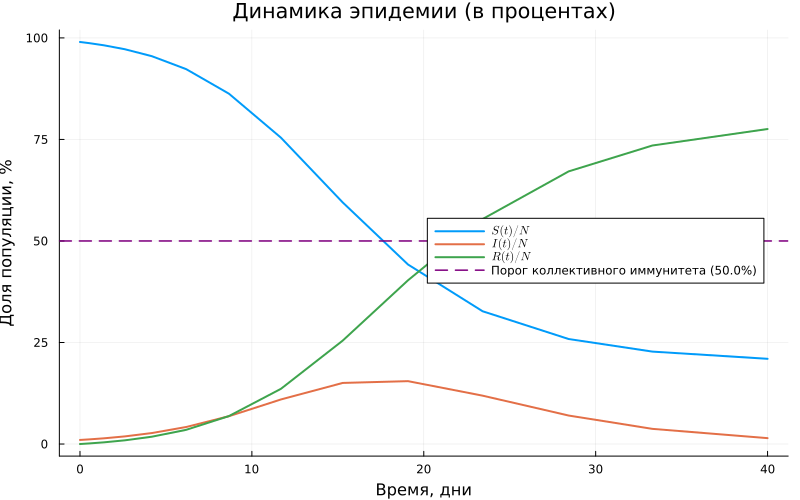

In [10]:
plt4 = @df df_ode plot(:t, [:S :I :R] ./ df_ode.N .* 100,
    label     = [L"S(t)/N" L"I(t)/N" L"R(t)/N"],
    xlabel    = "Время, дни",
    ylabel    = "Доля популяции, %",
    title     = "Динамика эпидемии (в процентах)",
    linewidth = 2,
    legend    = :right,
    grid      = true,
    size      = (800, 500))
if R0 > 1
    herd_immunity_threshold = (1 - 1/R0) * 100
    hline!(plt4, [herd_immunity_threshold], color=:purple, linestyle=:dash,
        label="Порог коллективного иммунитета ($(round(herd_immunity_threshold, digits=1))%)",
        linewidth=1.5)
end

### График 5: Фазовый портрет (I vs S)

Траектория в координатах $(S, I)$ всегда движется вправо→влево:
запасы восприимчивых убывают монотонно.

In [11]:
plt5 = plot(df_ode.S, df_ode.I,
    label     = "Фазовая траектория",
    xlabel    = L"S(t)",
    ylabel    = L"I(t)",
    title     = "Фазовый портрет SIR модели",
    color     = :blue,
    linewidth = 2,
    grid      = true,
    size      = (800, 500),
    legend    = :topright)
for i in 1:50:length(df_ode.S)-1
    plot!(plt5, [df_ode.S[i], df_ode.S[i+1]], [df_ode.I[i], df_ode.I[i+1]],
        arrow=:closed, color=:blue, alpha=0.5, label=false)
end

### График 6: Эффективное репродуктивное число $R_e(t)$

$$R_e(t) = R_0 \cdot \frac{S(t)}{N}$$

Когда $R_e$ падает ниже 1, число инфицированных начинает убывать.

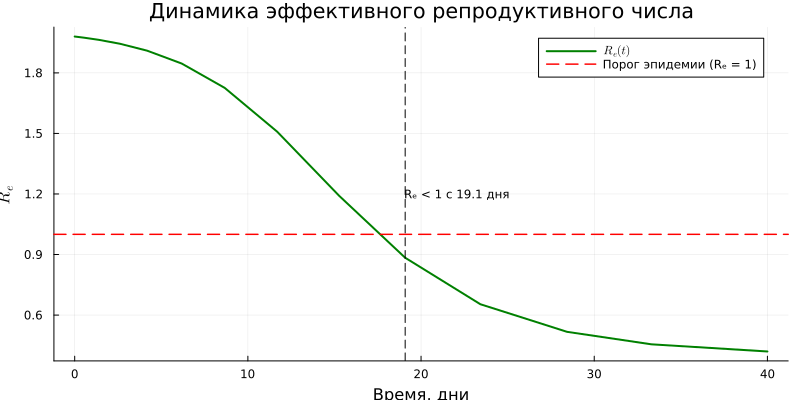

In [12]:
df_ode[!, :Re] = R0 .* df_ode.S ./ df_ode.N

plt6 = @df df_ode plot(:t, :Re,
    label     = L"R_e(t)",
    xlabel    = "Время, дни",
    ylabel    = L"R_e",
    title     = "Динамика эффективного репродуктивного числа",
    color     = :green,
    linewidth = 2,
    grid      = true,
    size      = (800, 400))
hline!(plt6, [1.0], color=:red, linestyle=:dash,
    label="Порог эпидемии (Rₑ = 1)", linewidth=1.5)

cross_idx = findfirst(x -> x < 1, df_ode.Re)
if !isnothing(cross_idx) && cross_idx > 1
    cross_time = df_ode.t[cross_idx]
    vline!(plt6, [cross_time], color=:black, linestyle=:dash, label=false, linewidth=1)
    annotate!(plt6, cross_time, 1.2,
        text("Rₑ < 1 с $(round(cross_time, digits=1)) дня", 8, :left))
end

### График 7: Сводная панель

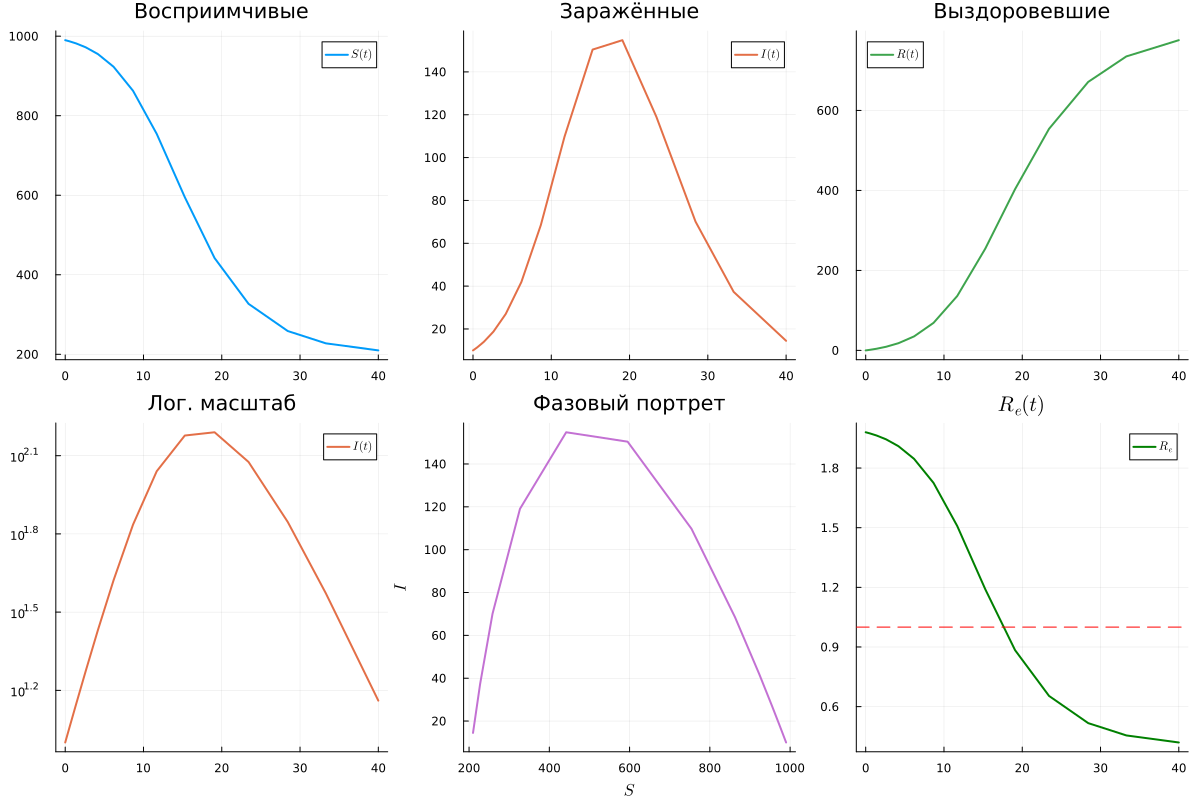

In [13]:
plt7 = plot(layout=(2, 3), size=(1200, 800))
plot!(plt7[1], df_ode.t, df_ode.S, label=L"S(t)", color=1, linewidth=2, title="Восприимчивые")
plot!(plt7[2], df_ode.t, df_ode.I, label=L"I(t)", color=2, linewidth=2, title="Заражённые")
plot!(plt7[3], df_ode.t, df_ode.R, label=L"R(t)", color=3, linewidth=2, title="Выздоровевшие")
plot!(plt7[4], df_ode.t, df_ode.I, label=L"I(t)", color=2, linewidth=2,
    yscale=:log10, title="Лог. масштаб")
plot!(plt7[5], df_ode.S, df_ode.I, label=false, color=4, linewidth=2,
    title="Фазовый портрет", xlabel=L"S", ylabel=L"I")
plot!(plt7[6], df_ode.t, df_ode.Re, label=L"R_e", color=:green, linewidth=2,
    title=L"R_e(t)")
hline!(plt7[6], [1.0], color=:red, linestyle=:dash, label=false)

## Анализ результатов и эпидемиологические выводы

In [14]:
println("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ===")
println("Общая численность популяции (контроль сохранения): N = $(round(df_ode.N[1], digits=1))")
println("Пиковое число заражённых:    I_max = $(round(peak_value,           digits=1))")
println("Время достижения пика:       t_peak = $(round(peak_time,           digits=1)) дней")
println("Итоговое число переболевших: R(∞)  = $(round(df_ode.R[end],       digits=1))")
println("Доля переболевших:           $(round(df_ode.R[end]/df_ode.N[1]*100, digits=1))%")
if R0 > 1
    println("\nТеоретический анализ:")
    println("  Порог коллективного иммунитета: $(round((1-1/R0)*100, digits=1))%")
    println("  Пик ожидается при S/N = 1/R₀ = $(round(1/R0, digits=3))")
end


=== АНАЛИЗ РЕЗУЛЬТАТОВ ===
Общая численность популяции (контроль сохранения): N = 1000.0
Пиковое число заражённых:    I_max = 154.8
Время достижения пика:       t_peak = 19.1 дней
Итоговое число переболевших: R(∞)  = 775.7
Доля переболевших:           77.6%

Теоретический анализ:
  Порог коллективного иммунитета: 50.0%
  Пик ожидается при S/N = 1/R₀ = 0.5


## Анализ чувствительности: влияние $R_0$ на развитие эпидемии

Базовое репродуктивное число $R_0 = c\beta/\gamma$ — главный параметр модели SIR.
Варьируем $\beta$ при фиксированных $c = 10$ и $\gamma = 0.25$,
получая $R_0$ от 0.5 до 4.0.

| Сценарий        | $\beta$ | $R_0$ | Аналог                   |
|-----------------|---------|-------|--------------------------|
| Затухание       | 0.0125  | 0.5   | неэффективная передача   |
| Порог эпидемии  | 0.0250  | 1.0   | граница распространения  |
| Умеренный       | 0.0500  | 2.0   | базовый (грипп-подобный) |
| Высокий         | 0.0750  | 3.0   | корь-подобный            |
| Очень высокий   | 0.1000  | 4.0   | высокая контагиозность   |

При $R_0 \le 1$ эпидемия не развивается. При $R_0 > 1$ охват эпидемии
и пиковое число заражённых возрастают нелинейно.

In [15]:
param_sets_sir = [
    (label="R₀=0.5",  β=0.0125, c=10.0, γ=0.25),
    (label="R₀=1.0",  β=0.0250, c=10.0, γ=0.25),
    (label="R₀=2.0",  β=0.0500, c=10.0, γ=0.25),
    (label="R₀=3.0",  β=0.0750, c=10.0, γ=0.25),
    (label="R₀=4.0",  β=0.1000, c=10.0, γ=0.25),
]

5-element Vector{@NamedTuple{label::String, β::Float64, c::Float64, γ::Float64}}:
 (label = "R₀=0.5", β = 0.0125, c = 10.0, γ = 0.25)
 (label = "R₀=1.0", β = 0.025, c = 10.0, γ = 0.25)
 (label = "R₀=2.0", β = 0.05, c = 10.0, γ = 0.25)
 (label = "R₀=3.0", β = 0.075, c = 10.0, γ = 0.25)
 (label = "R₀=4.0", β = 0.1, c = 10.0, γ = 0.25)

Прогоняем модель для каждого значения $R_0$.
Фиксируем: пиковое число заражённых, время пика, итоговый охват, порог иммунитета.

In [16]:
sweep_results_sir = DataFrame(
    сценарий         = String[],
    R0               = Float64[],
    I_max            = Float64[],
    t_peak           = Float64[],
    R_final          = Float64[],
    охват_процент    = Float64[],
    порог_иммунитета = Float64[],
)

solutions_sir = []
N_base = u0[1] + u0[2] + u0[3]

for ps in param_sets_sir
    p_test  = [ps.β, ps.c, ps.γ]
    R0_test = ps.c * ps.β / ps.γ

    prob_test = ODEProblem(sir_ode!, u0, tspan, p_test)
    sol_test  = solve(prob_test, dt=δt)

    df_test = DataFrame(Tables.table(sol_test'))
    rename!(df_test, ["S", "I", "R"])
    df_test[!, :t]  = sol_test.t
    df_test[!, :Re] = R0_test .* df_test.S ./ N_base

    I_max_test  = maximum(df_test.I)
    t_peak_test = df_test.t[argmax(df_test.I)]
    R_fin_test  = df_test.R[end]
    herd_test   = R0_test > 1 ? (1 - 1/R0_test) * 100 : 0.0

    push!(solutions_sir, (
        t  = df_test.t,
        S  = df_test.S,
        I  = df_test.I,
        R  = df_test.R,
        Re = df_test.Re,
        label = ps.label,
        R0    = R0_test,
    ))
    push!(sweep_results_sir, (
        ps.label,
        round(R0_test,               digits=2),
        round(I_max_test,            digits=1),
        round(t_peak_test,           digits=1),
        round(R_fin_test,            digits=1),
        round(R_fin_test/N_base*100, digits=1),
        round(herd_test,             digits=1),
    ))
end

println("\n" * "="^60)
println("Результаты анализа чувствительности SIR по R₀")
println("="^60)
println(sweep_results_sir)

Результаты анализа чувствительности SIR по R₀
5×7 DataFrame
 Row │ сценарий  R0       I_max    t_peak   R_final  охват_процент  порог_иммунитета 
     │ String    Float64  Float64  Float64  Float64  Float64        Float64          
─────┼───────────────────────────────────────────────────────────────────────────────
   1 │ R₀=0.5        0.5     10.0      0.0     19.6            2.0               0.0
   2 │ R₀=1.0        1.0     10.0      0.0     82.8            8.3               0.0
   3 │ R₀=2.0        2.0    154.8     19.1    775.7           77.6              50.0
   4 │ R₀=3.0        3.0    299.4     10.0    939.3           93.9              66.7
   5 │ R₀=4.0        4.0    400.6      8.3    979.9           98.0              75.0


### График S1: Кривые $I(t)$ при разных $R_0$

Чем выше $R_0$, тем круче подъём, выше пик и раньше достигается максимум.

In [17]:
plt_r1 = plot(xlabel="Время, дни", ylabel="Инфицированные I(t)",
    title="Динамика заражённых при разных R₀",
    grid=true, size=(900, 500), legend=:topright)
for (i, s) in enumerate(solutions_sir)
    plot!(plt_r1, s.t, s.I, label=s.label, linewidth=2, color=i)
end

### График S2: Эффективное репродуктивное число $R_e(t)$

При $R_0 \le 1$ кривая $R_e$ начинается ниже порога 1 и не приводит
к заметной эпидемии. При $R_0 > 1$ — пересечение $R_e = 1$ отмечает
момент начала спада.

In [18]:
plt_r2 = plot(xlabel="Время, дни", ylabel=L"R_e(t)",
    title="Эффективное репродуктивное число при разных R₀",
    grid=true, size=(900, 500), legend=:topright)
hline!(plt_r2, [1.0], color=:black, linestyle=:dash, linewidth=1.5, label="Rₑ = 1")
for (i, s) in enumerate(solutions_sir)
    plot!(plt_r2, s.t, s.Re, label=s.label, linewidth=2, color=i)
end

### График S3: Итоговые показатели в зависимости от $R_0$

Нелинейный рост охвата и пикового числа заражённых с увеличением $R_0$:
особенно резкое изменение вблизи порогового значения $R_0 = 1$.

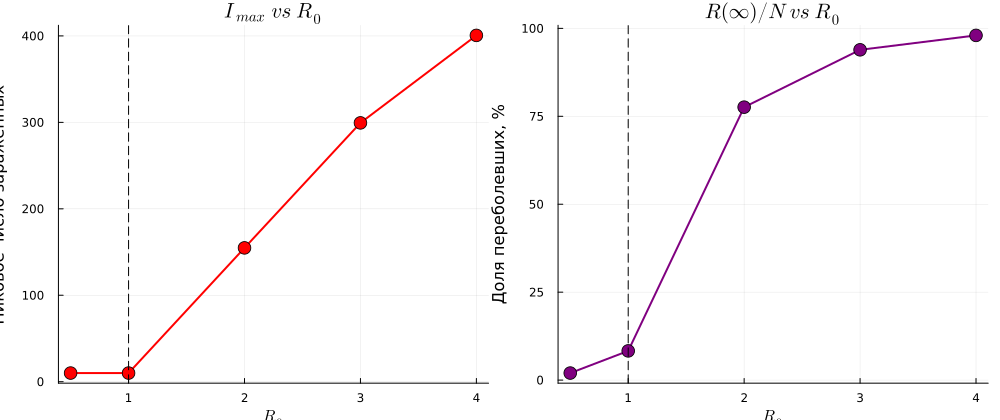

In [19]:
R0_vals    = sweep_results_sir.R0
I_max_vals = sweep_results_sir.I_max
cover_vals = sweep_results_sir.охват_процент

plt_r3 = plot(layout=(1, 2), size=(1000, 420))
plot!(plt_r3[1], R0_vals, I_max_vals,
    xlabel=L"R_0", ylabel="Пиковое число заражённых",
    title=L"I_{max} \; vs \; R_0",
    marker=:circle, markersize=7, linewidth=2, color=:red,
    legend=false, grid=true)
vline!(plt_r3[1], [1.0], color=:black, linestyle=:dash, label=false)

plot!(plt_r3[2], R0_vals, cover_vals,
    xlabel=L"R_0", ylabel="Доля переболевших, %",
    title=L"R(\infty)/N \; vs \; R_0",
    marker=:circle, markersize=7, linewidth=2, color=:purple,
    legend=false, grid=true)
vline!(plt_r3[2], [1.0], color=:black, linestyle=:dash, label=false)

### График S4: Сводная панель анализа чувствительности

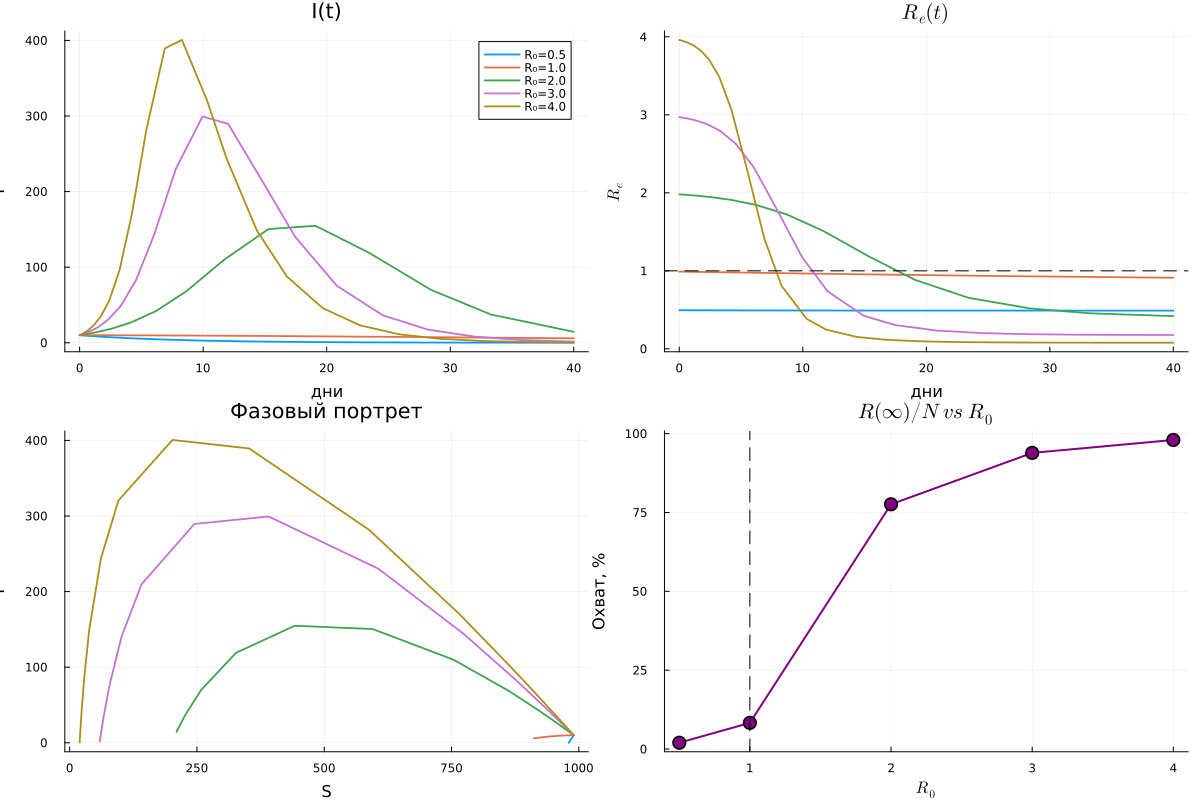

In [20]:
plt_r4 = plot(layout=(2, 2), size=(1200, 800))
for (i, s) in enumerate(solutions_sir)
    plot!(plt_r4[1], s.t, s.I,
        label=s.label, color=i, linewidth=1.8,
        title="I(t)", xlabel="дни", ylabel="I", legend=:topright, grid=true)
    plot!(plt_r4[2], s.t, s.Re,
        label=false, color=i, linewidth=1.8,
        title=L"R_e(t)", xlabel="дни", ylabel=L"R_e", grid=true)
    plot!(plt_r4[3], s.S, s.I,
        label=false, color=i, linewidth=1.8,
        title="Фазовый портрет", xlabel="S", ylabel="I", grid=true)
end
hline!(plt_r4[2], [1.0], color=:black, linestyle=:dash, label=false)
plot!(plt_r4[4], R0_vals, cover_vals,
    xlabel=L"R_0", ylabel="Охват, %", title=L"R(\infty)/N \; vs \; R_0",
    marker=:circle, markersize=7, linewidth=2, color=:purple,
    legend=false, grid=true)
vline!(plt_r4[4], [1.0], color=:black, linestyle=:dash, label=false)

## Бенчмарк производительности

Оцениваем время одного численного решения задачи.

In [21]:
@benchmark solve(prob_ode, dt = δt)

BenchmarkTools.Trial: 10000 samples with 6 evaluations per sample.
 Range (min … max):  5.041 μs …  7.818 ms  ┊ GC (min … max): 0.00% … 99.78%
 Time  (median):     7.698 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   8.137 μs ± 78.128 μs  ┊ GC (mean ± σ):  9.59% ±  1.00%

   ▆█                                                         
  ▃██▇▃▂▃▄▃▂▁▁▁▁▁▁▂▃▄▆▇▇▆▅▄▃▃▄▅▅▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  5.04 μs        Histogram: frequency by time        12.8 μs <

 Memory estimate: 16.97 KiB, allocs estimate: 330.